LDA 

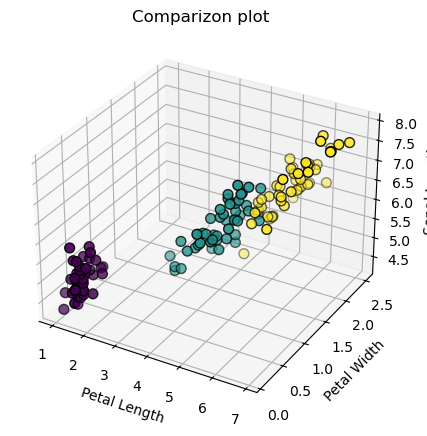

In [23]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 

from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import train_test_split 

df = pd.read_csv("d:\\AppstoneLab-AI-intern\\Day-wise\\Day-4\\Iris.csv")
df = df.drop(columns=["Id"])
y = df["Species"].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})
X = df.drop(columns=["Species"])


fig = plt.figure(figsize=(5,7))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X["PetalLengthCm"],X["PetalWidthCm"],X["SepalLengthCm"],c=y,edgecolors="k",s=50)
ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
ax.set_zlabel("Sepal Length")
ax.set_title("Comparizon plot ")
plt.show()

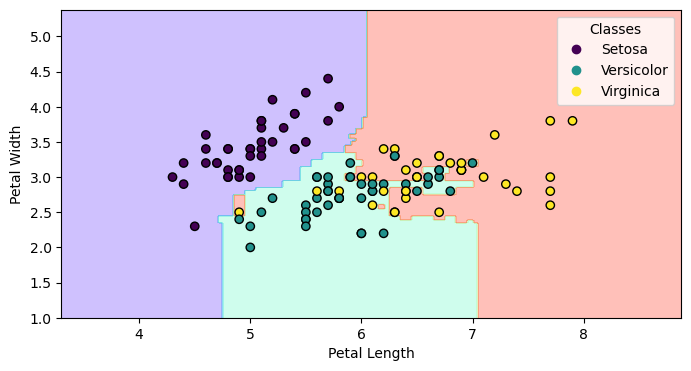

In [ ]:
RF = RandomForestClassifier(
    n_estimators=150,
    criterion = "gini",
    max_depth= 6,
    random_state = 45
)

x_train,x_test,y_train,y_test = train_test_split(np.array(X),y,train_size=0.8,random_state=45)
RF.fit(x_train[:,:2],y_train)
x_train_2d = x_train[:,:2]
x_min,x_max = x_train_2d[:,0].min() - 1 , x_train_2d[:,0].max() + 1 
y_min,y_max = x_train_2d[:,1].min() - 1 , x_train_2d[:,1].max() + 1 

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))

Z = RF.predict(np.c_[xx.ravel(),yy.ravel()])    
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,4))
plt.contourf(xx,yy,Z,alpha=0.3,cmap="rainbow")
sc = plt.scatter(x_train_2d[:,0],x_train_2d[:,1],c=y_train,edgecolors="k")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
handles, _ = sc.legend_elements()
labels = ["Setosa", "Versicolor", "Virginica"]
plt.legend(handles=handles, labels=labels, title="Classes")
plt.show()

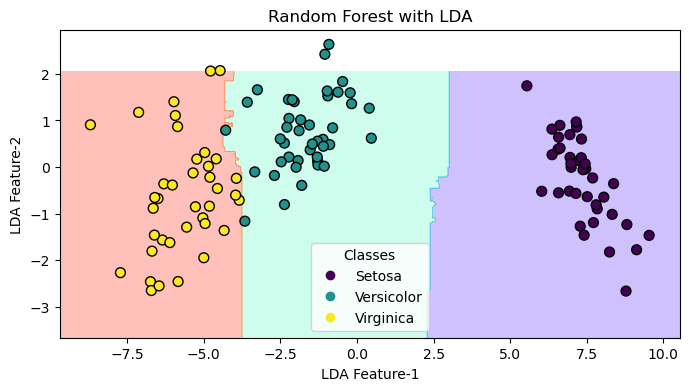

In [66]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

RF_lda = RandomForestClassifier(
    n_estimators=150,
    criterion = "gini",
    max_depth= 6,
    random_state = 45
)
lda = LinearDiscriminantAnalysis(n_components=2)
x_train_lda = lda.fit_transform(x_train,y_train)
x_test_lda = lda.transform(x_test)

x_min,x_max = x_train_lda[:,0].min()-1, x_train_lda[:,0].max() + 1 
y_min,y_max = x_train_lda[:,1].min()-1, x_train_lda[:1].max() + 1 

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))

RF_lda.fit(x_train_lda,y_train)
Z = RF_lda.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,4))
plt.contourf(xx,yy,Z,cmap="rainbow",alpha=0.3)
sc = plt.scatter(x_train_lda[:,0],x_train_lda[:,1],s=50,c=y_train,edgecolors="k")
plt.xlabel("LDA Feature-1")
plt.ylabel("LDA Feature-2")
plt.title("Random Forest with LDA")

handles,_ = sc.legend_elements() 
plt.legend(handles=handles, labels=labels, title="Classes")
plt.show()

t-SNE Visualization

In [69]:
import seaborn as sns 
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',version=1)
data = mnist.data
target = mnist.target 

df = pd.DataFrame(data)
df["label"] = target 
print(df.head())

   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel776  pixel777  pixel778  pixel779  pixel780  pixel781  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0         0         0         0   
3        0  ...         0         0         0         0         0         0   
4        0  ...         0         0         0         0         0         0   

   pixel782  pixel783  pixel784  label  
0         0         0

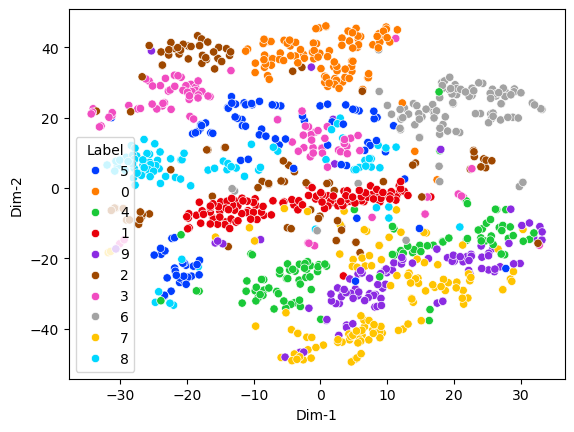

In [71]:
scaler = StandardScaler()
Standardized_data = scaler.fit_transform(df)

data = Standardized_data[:1000,:]
label = target[:1000]

model = TSNE(n_components = 2,random_state=45)
tsne_data = model.fit_transform(data)

tsne_data = np.vstack((tsne_data.T,label)).T
tsne_df = pd.DataFrame(
    data = tsne_data,
    columns = ("Dim-1","Dim-2","Label")
)

sns.scatterplot(
    data = tsne_df,
    x = "Dim-1",
    y = "Dim-2",
    hue="Label",
    palette="bright"
)
plt.show()

Mini-Project : 2D Visualizer 

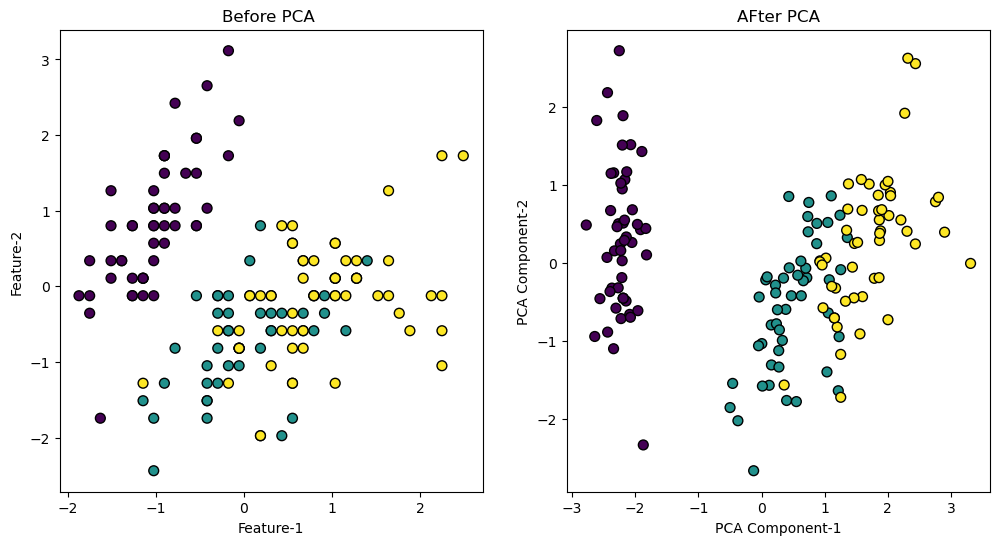

In [73]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler 
df = pd.read_csv("d:\\AppstoneLab-AI-intern\\Day-wise\\Day-4\\Iris.csv")
df = df.drop(columns=["Id"])
Y = df["Species"].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})
X = df.drop(columns=["Species"])

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_model = PCA(n_components=2)

X_selected = pca_model.fit_transform(X_scaled)


plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=Y,s=50,edgecolors="k")
plt.title("Before PCA ")
plt.xlabel("Feature-1")
plt.ylabel("Feature-2")


plt.subplot(1,2,2)
plt.scatter(X_selected[:,0],X_selected[:,1],c=Y,s=50,edgecolor="k")
plt.xlabel("PCA Component-1")
plt.ylabel("PCA Component-2")
plt.title("AFter PCA")
plt.show()



